In [1]:
pip install tensorflow matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# !wget https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/36b1c47d-8e0f-4c10-92b2-5a87fcb46e7d/file_downloaded

download data set from 
small dataset : https://www.kaggle.com/datasets/emmarex/plantdisease?resource=download
big dataset : https://data.mendeley.com/datasets/tywbtsjrjv/1
and run python split_dataset.py
 


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

validation_data = test_datagen.flow_from_directory(
    "dataset/validation",
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 16504 images belonging to 15 classes.
Found 4134 images belonging to 15 classes.


In [5]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [6]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_data.num_classes,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\visha\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 100s 191ms/step - accuracy: 0.3655 - loss: 1.9436 - val_accuracy: 0.6018 - val_loss: 1.2055
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 97s 187ms/step - accuracy: 0.5864 - loss: 1.2493 - val_accuracy: 0.6788 - val_loss: 0.9544
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 96s 186ms/step - accuracy: 0.6514 - loss: 1.0368 - val_accuracy: 0.7542 - val_loss: 0.7369
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 97s 188ms/step - accuracy: 0.6859 - loss: 0.9224 - val_accuracy: 0.7719 - val_loss: 0.6758
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 95s 184ms/step - accuracy: 0.7023 - loss: 0.8578 - val_accuracy: 0.7791 - val_loss: 0.6484
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 94s 182ms/step - accuracy: 0.7310 - loss: 0.7876 - val_accuracy: 0.8314 - val_loss: 0.4866
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 94s 183ms/step - accuracy: 0.7367 - loss: 0.7473 - val_accuracy: 0.8529 - val_loss: 0.4499
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 94s 182ms/step - accuracy: 0.7567 - loss: 

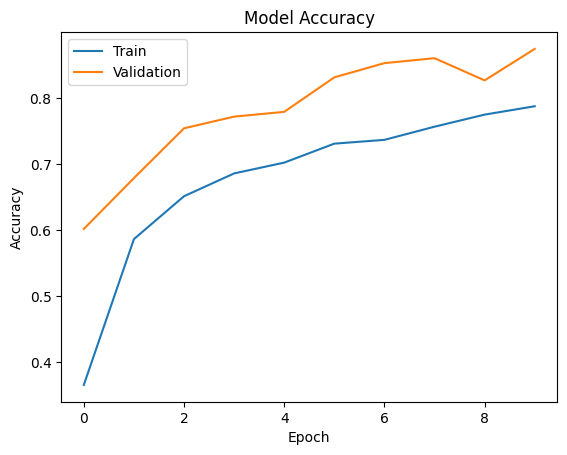

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])

plt.show()

In [9]:
model.save("plant_disease_model.h5")

In [21]:
from tensorflow.keras.preprocessing import image

img = image.load_img("dataset\\validation\\Tomato__Target_Spot\\0a3b6099-c254-4bc3-8360-53a9f558a0c4___Com.G_TgS_FL 8259.JPG",target_size=(128,128))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array,axis=0)
img_array = img_array/255.0

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]

print("Predicted Disease:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Disease: Tomato__Target_Spot
